In [1]:
from google.colab import files

uploaded = files.upload()

Saving Training Data.csv to Training Data.csv
Saving Validation Data.csv to Validation Data.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

df_train = pd.read_csv(io.BytesIO(uploaded['Training Data.csv']))
df_val = pd.read_csv(io.BytesIO(uploaded['Validation Data.csv']))
print(df_train.head())
print(df_val.head())

    x1   x2   x3   x4  target
0  5.1  3.5  1.4  0.2       0
1  4.9  3.0  1.4  0.2       0
2  4.7  3.2  1.3  0.2       0
3  4.6  3.1  1.5  0.2       0
4  5.0  3.6  1.4  0.2       0
    x1   x2   x3   x4  target
0  5.0  3.5  1.3  0.3       0
1  4.5  2.3  1.3  0.3       0
2  4.4  3.2  1.3  0.2       0
3  5.0  3.5  1.6  0.6       0
4  5.1  3.8  1.9  0.4       0


In [3]:
X_train = df_train[['x1', 'x2', 'x3', 'x4']].values
y_train = df_train['target'].values
X_val = df_val[['x1', 'x2', 'x3', 'x4']].values
y_val = df_val['target'].values

In [4]:
# parameter
w = np.array([0.5, 0.5, 0.5, 0.5])
b = 0.5
lr = 0.1
epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# g(z)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [5]:
# loop epoch
for epoch in range(epochs):
    sse_train = 0
    correct_train = 0

    # data training
    for i in range(len(X_train)):
        xi = X_train[i]
        yi = y_train[i]

        # hitung z, g(z), dan prediction
        z = np.dot(w, xi) + b
        g = sigmoid(z)
        pred = 1 if g >= 0.5 else 0

        # hitung error & SSE
        error = g - yi
        sse_train += error ** 2
        if pred == yi:
            correct_train += 1

        # algoritma optimasi (gradient descent)
        db = 2 * error * g * (1 - g)
        dw = db * xi
        b = b - (lr * db)
        w = w - (lr * dw)

    train_losses.append(sse_train / len(X_train))
    train_accs.append(correct_train / len(X_train))

    # data validation
    sse_val = 0
    correct_val = 0
    for i in range(len(X_val)):
        xi = X_val[i]
        yi = y_val[i]

        z = np.dot(w, xi) + b
        g = sigmoid(z)
        pred = 1 if g >= 0.5 else 0

        error = g - yi
        sse_val += error ** 2
        if pred == yi:
            correct_val += 1

    val_losses.append(sse_val / len(X_val))
    val_accs.append(correct_val / len(X_val))

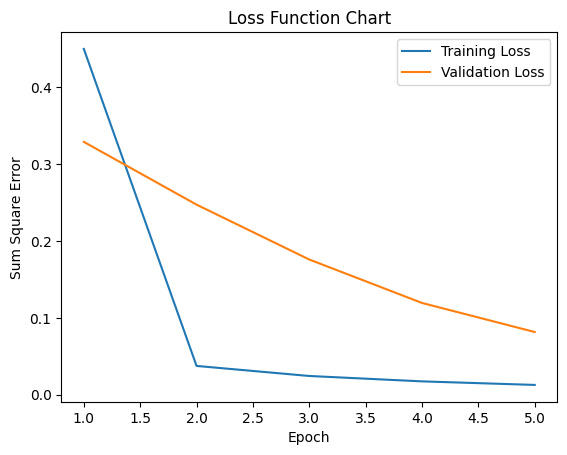

In [6]:
new_epochs = len(train_losses)
plt.plot(range(1, new_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, new_epochs + 1), val_losses, label='Validation Loss')
plt.title('Loss Function Chart')
plt.xlabel('Epoch')
plt.ylabel('Sum Square Error')
plt.legend()
plt.show()

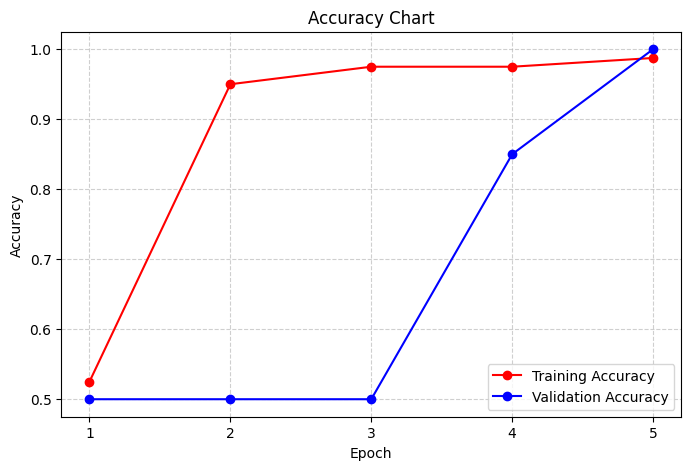

In [7]:
new_epochs = len(train_accs)
plt.figure(figsize=(8, 5))
plt.plot(range(1, new_epochs + 1), train_accs, marker='o', color='red', label='Training Accuracy')
plt.plot(range(1, new_epochs + 1), val_accs, marker='o', color='blue', label='Validation Accuracy')

plt.title('Accuracy Chart')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(1, new_epochs + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()